## a) Diagrama de transição de estados

Desenhar o diagrama de transição de estados da cadeia de Markov do sensor inteligente, incluindo as probabilidades de permanência, degradação, recuperação parcial e absorção no estado 4.


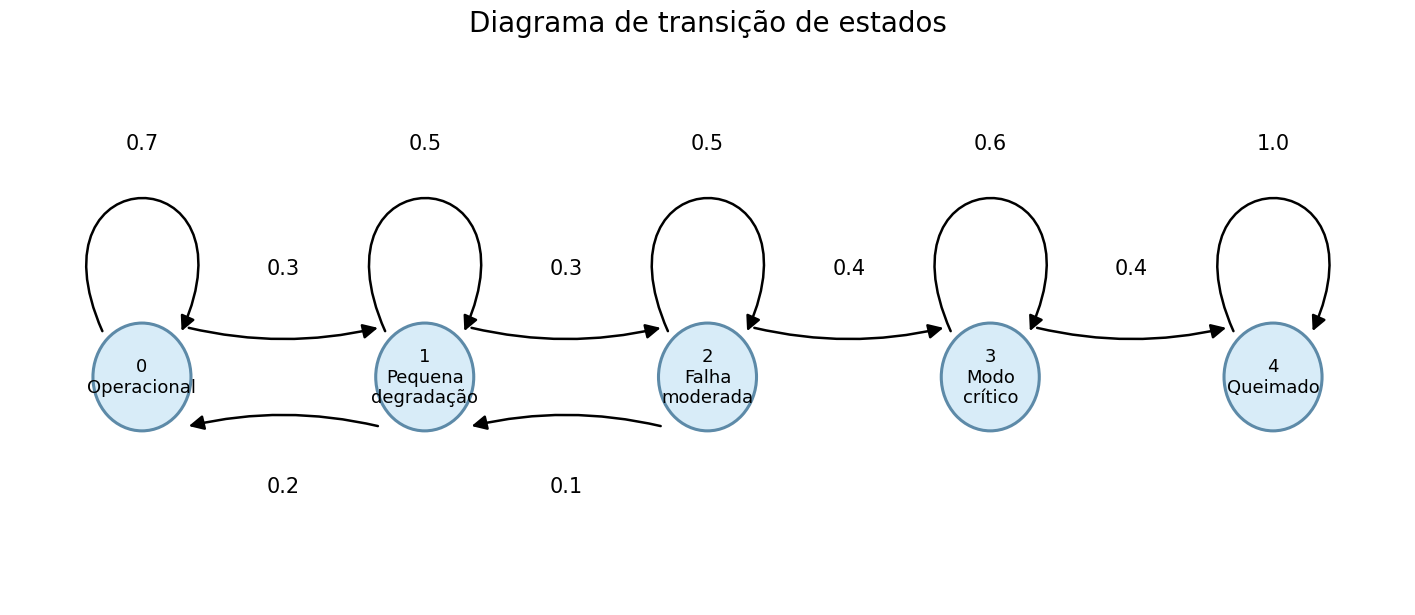

In [8]:
# a) Desenhar o diagrama de transição de estados.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.path import Path


SEED = 42

P = np.array([
    [0.7, 0.3, 0.0, 0.0, 0.0],
    [0.2, 0.5, 0.3, 0.0, 0.0],
    [0.0, 0.1, 0.5, 0.4, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 0.0, 1.0],
])

labels = [
    "0\nOperacional",
    "1\nPequena\ndegradação",
    "2\nFalha\nmoderada",
    "3\nModo\ncrítico",
    "4\nQueimado",
]

positions = {
    0: (0.0, 0.0),
    1: (3.0, 0.0),
    2: (6.0, 0.0),
    3: (9.0, 0.0),
    4: (12.0, 0.0),
}

fig, ax = plt.subplots(figsize=(18, 7))
ax.set_title("Diagrama de transição de estados", fontsize=20, pad=25)
ax.set_xlim(-1.4, 13.4)
ax.set_ylim(-2.2, 3.0)
ax.axis("off")

node_radius = 0.52

for state, (x, y) in positions.items():
    node = Circle((x, y), node_radius, facecolor="#d8ecf8", edgecolor="#5d8aa8", linewidth=2.2)
    ax.add_patch(node)
    ax.text(x, y, labels[state], ha="center", va="center", fontsize=13)

# Self-loops are drawn as external arcs above each state to avoid crossing the node text.
for state, probability in [(0, 0.7), (1, 0.5), (2, 0.5), (3, 0.6), (4, 1.0)]:
    x, y = positions[state]
    loop_path = Path(
        [
            (x - 0.42, y + node_radius * 0.85),
            (x - 1.25, y + 2.15),
            (x + 1.25, y + 2.15),
            (x + 0.42, y + node_radius * 0.85),
        ],
        [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4],
    )
    loop = FancyArrowPatch(
        path=loop_path,
        arrowstyle="-|>",
        mutation_scale=22,
        linewidth=1.8,
        color="black",
    )
    ax.add_patch(loop)
    ax.text(x, y + 2.25, f"{probability:.1f}", ha="center", va="center", fontsize=15)

# Forward degradation arrows are above the horizontal axis.
forward_edges = [(0, 1, 0.3), (1, 2, 0.3), (2, 3, 0.4), (3, 4, 0.4)]
for origin, destination, probability in forward_edges:
    x0, y0 = positions[origin]
    x1, y1 = positions[destination]
    arrow = FancyArrowPatch(
        (x0 + node_radius * 0.9, y0 + 0.48),
        (x1 - node_radius * 0.9, y1 + 0.48),
        connectionstyle="arc3,rad=0.12",
        arrowstyle="-|>",
        mutation_scale=22,
        linewidth=1.8,
        color="black",
    )
    ax.add_patch(arrow)
    ax.text((x0 + x1) / 2, y0 + 1.05, f"{probability:.1f}", ha="center", va="center", fontsize=15)

# Recovery arrows are below the horizontal axis, avoiding label overlap with degradation arrows.
recovery_edges = [(1, 0, 0.2), (2, 1, 0.1)]
for origin, destination, probability in recovery_edges:
    x0, y0 = positions[origin]
    x1, y1 = positions[destination]
    arrow = FancyArrowPatch(
        (x0 - node_radius * 0.9, y0 - 0.48),
        (x1 + node_radius * 0.9, y1 - 0.48),
        connectionstyle="arc3,rad=0.12",
        arrowstyle="-|>",
        mutation_scale=22,
        linewidth=1.8,
        color="black",
    )
    ax.add_patch(arrow)
    ax.text((x0 + x1) / 2, y0 - 1.05, f"{probability:.1f}", ha="center", va="center", fontsize=15)

plt.show()


## b) Matriz de transição

Montar a matriz de transição da cadeia de Markov, mantendo as linhas como estados atuais e as colunas como próximos estados.


In [9]:
# b) Montar a matriz de transição da cadeia de Markov.
estados = [f"Estado {estado}" for estado in range(5)]
tabela_p = pd.DataFrame(P, index=estados, columns=estados)
tabela_somas = pd.DataFrame({"Soma": P.sum(axis=1)}, index=estados)

print("Matriz de transição P:")
display(tabela_p)
print("Soma das linhas:")
display(tabela_somas)


Matriz de transição P:


,Estado 0,Estado 1,Estado 2,Estado 3,Estado 4
Estado 0,0.7,0.3,0.0,0.0,0.0
Estado 1,0.2,0.5,0.3,0.0,0.0
Estado 2,0.0,0.1,0.5,0.4,0.0
Estado 3,0.0,0.0,0.0,0.6,0.4
Estado 4,0.0,0.0,0.0,0.0,1.0


Soma das linhas:


,Soma
Estado 0,1.0
Estado 1,1.0
Estado 2,1.0
Estado 3,1.0
Estado 4,1.0


## c) Probabilidade de falha total no 4º ciclo

Considerando que o sensor inicia no estado 0, calcular a probabilidade de o sensor atingir o estado de falha total exatamente no 4º ciclo.


In [10]:
# c) Calcular a probabilidade de atingir a falha total exatamente no 4º ciclo.
P4 = np.linalg.matrix_power(P, 4)
probabilidade_ciclo_4 = P4[0, 4]

tabela_p4 = pd.DataFrame(P4, index=estados, columns=estados)

print("Matriz P^4:")
display(tabela_p4)
print(f"\nP(X_4 = 4 | X_0 = 0) = {probabilidade_ciclo_4:.4f}")


Matriz P^4:


,Estado 0,Estado 1,Estado 2,Estado 3,Estado 4
Estado 0,0.3907,0.3294,0.1827,0.0828,0.0144
Estado 1,0.2196,0.2320,0.2076,0.2160,0.1248
Estado 2,0.0406,0.0692,0.1102,0.2936,0.4864
Estado 3,0.0000,0.0000,0.0000,0.1296,0.8704
Estado 4,0.0000,0.0000,0.0000,0.0000,1.0000



P(X_4 = 4 | X_0 = 0) = 0.0144


## d) Matriz fundamental

Determinar a matriz fundamental da cadeia absorvente usando os estados transitórios 0, 1, 2 e 3.


In [11]:
# d) Determinar a matriz fundamental da cadeia.
Q = P[:4, :4]
I = np.eye(4)
N = np.linalg.inv(I - Q)

estados_transitorios = [f"Estado {estado}" for estado in range(4)]
tabela_q = pd.DataFrame(Q, index=estados_transitorios, columns=estados_transitorios)
tabela_n = pd.DataFrame(N, index=estados_transitorios, columns=estados_transitorios)

print("Submatriz Q dos estados transitórios:")
display(tabela_q)
print("Matriz fundamental N = (I - Q)^(-1):")
display(tabela_n)


Submatriz Q dos estados transitórios:


,Estado 0,Estado 1,Estado 2,Estado 3
Estado 0,0.7,0.3,0.0,0.0
Estado 1,0.2,0.5,0.3,0.0
Estado 2,0.0,0.1,0.5,0.4
Estado 3,0.0,0.0,0.0,0.6


Matriz fundamental N = (I - Q)^(-1):


,Estado 0,Estado 1,Estado 2,Estado 3
Estado 0,6.111111,4.166667,2.5,2.5
Estado 1,2.777778,4.166667,2.5,2.5
Estado 2,0.555556,0.833333,2.5,2.5
Estado 3,0.000000,0.000000,0.0,2.5


## e) Número médio de ciclos até a absorção

Calcular o número médio de ciclos até que o sensor seja absorvido no estado de falha total.


In [12]:
# e) Calcular o número médio de ciclos até a absorção.
tempos_medios = N @ np.ones(4)

tabela_tempos = pd.DataFrame(
    {"Número médio de ciclos até absorção": tempos_medios},
    index=estados_transitorios,
)

display(tabela_tempos)


,Número médio de ciclos até absorção
Estado 0,15.277778
Estado 1,11.944444
Estado 2,6.388889
Estado 3,2.500000


## f) Probabilidade de absorção no estado de falha total

Determinar a probabilidade de absorção no estado 4 para cada estado inicial transitório.


In [13]:
# f) Determinar a probabilidade de absorção no estado de falha total.
R = P[:4, 4:]
B = N @ R

tabela_absorcao = pd.DataFrame(
    {"Probabilidade de absorção no estado 4": B[:, 0]},
    index=estados_transitorios,
)

display(tabela_absorcao)


,Probabilidade de absorção no estado 4
Estado 0,1.0
Estado 1,1.0
Estado 2,1.0
Estado 3,1.0


## g) Simulação e evolução temporal

Implementar um código em Python para simular a cadeia de Markov, calcular as probabilidades, plotar o grafo de transições e mostrar a evolução temporal das probabilidades dos estados.


Resultados da simulação por estado inicial:


,Pr{absorção estimada},E[ciclos até absorção] estimado,Absorções,Replicações
Estado inicial,,,,
Estado 0,1.0,15.2209,10000,10000
Estado 1,1.0,11.9142,10000,10000
Estado 2,1.0,6.4359,10000,10000
Estado 3,1.0,2.5063,10000,10000
Estado 4,1.0,0.0000,10000,10000


Evolução temporal das probabilidades dos estados:


,Pr{estado 0},Pr{estado 1},Pr{estado 2},Pr{estado 3},Pr{estado 4}
Ciclo,,,,,
0,1.000000,0.000000,0.000000,0.000000,0.000000
1,0.700000,0.300000,0.000000,0.000000,0.000000
2,0.550000,0.360000,0.090000,0.000000,0.000000
3,0.457000,0.354000,0.153000,0.036000,0.000000
4,0.390700,0.329400,0.182700,0.082800,0.014400
5,0.339370,0.300180,0.190170,0.122760,0.047520
6,0.297595,0.270918,0.185139,0.149724,0.096624
7,0.262500,0.243251,0.173845,0.163890,0.156514
8,0.232400,0.217760,0.159898,0.167872,0.222070


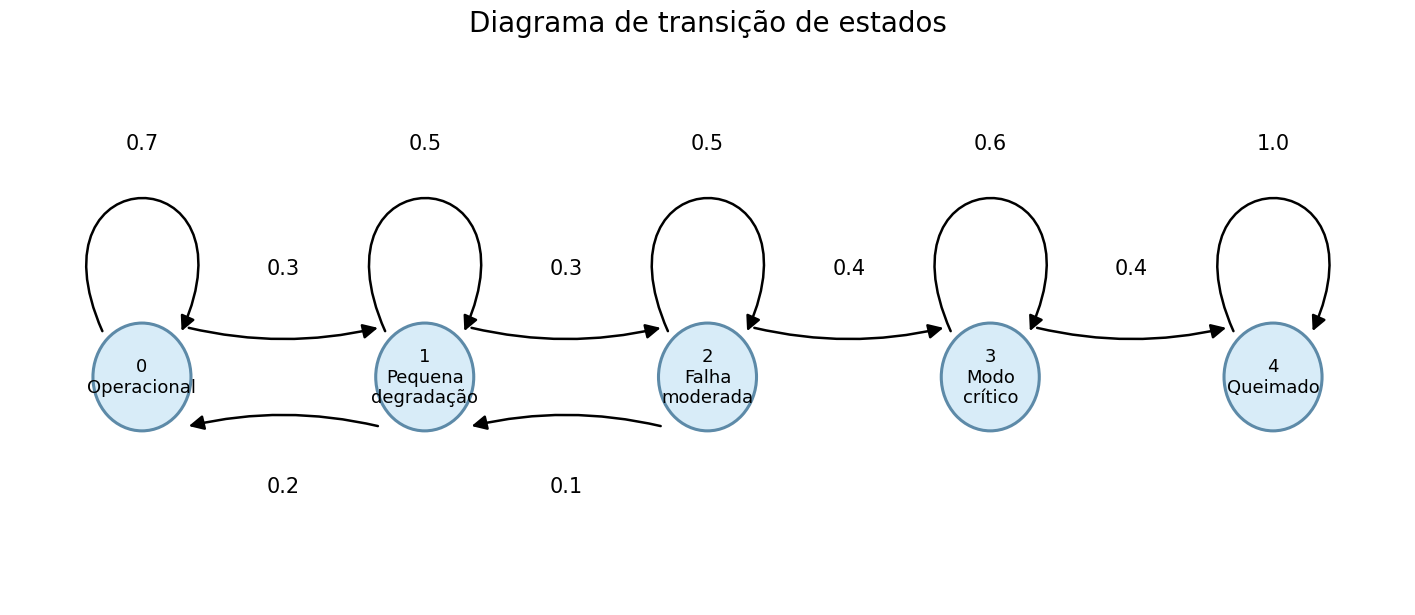

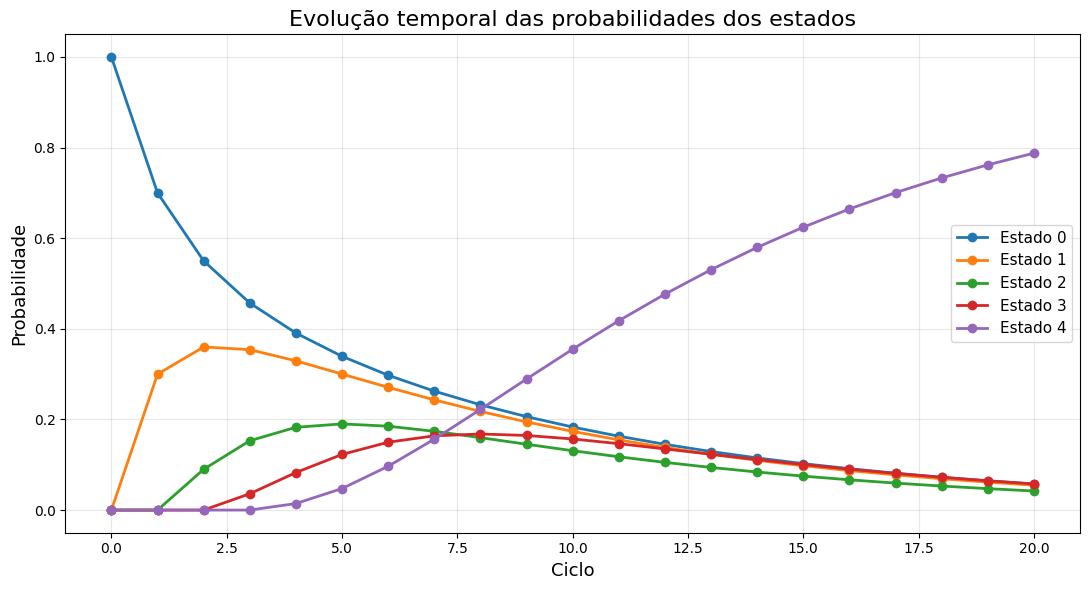

In [14]:
# g) Implementar simulação, cálculos, grafo de transições e evolução temporal.
rng = np.random.default_rng(SEED)
simulacoes = 10000
max_ciclos = 200
resultados_simulacao = []

for estado_inicial in range(5):
    ciclos_ate_absorcao = np.zeros(simulacoes, dtype=int)
    absorcoes = 0

    for simulacao in range(simulacoes):
        estado = estado_inicial
        ciclos = 0

        while estado != 4 and ciclos < max_ciclos:
            estado = rng.choice(np.arange(5), p=P[estado])
            ciclos += 1

        ciclos_ate_absorcao[simulacao] = ciclos

        if estado == 4:
            absorcoes += 1

    resultados_simulacao.append([
        absorcoes / simulacoes,
        ciclos_ate_absorcao.mean(),
        absorcoes,
        simulacoes,
    ])

tabela_simulacao = pd.DataFrame(
    resultados_simulacao,
    index=[f"Estado {estado}" for estado in range(5)],
    columns=[
        "Pr{absorção estimada}",
        "E[ciclos até absorção] estimado",
        "Absorções",
        "Replicações",
    ],
)
tabela_simulacao.index.name = "Estado inicial"

distribuicao = np.zeros((21, 5))
distribuicao[0, 0] = 1.0

for ciclo in range(1, 21):
    distribuicao[ciclo] = distribuicao[ciclo - 1] @ P

tabela_distribuicao = pd.DataFrame(
    distribuicao,
    columns=[f"Pr{{estado {estado}}}" for estado in range(5)],
)
tabela_distribuicao.index.name = "Ciclo"

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print("Resultados da simulação por estado inicial:")
display(tabela_simulacao)
print("Evolução temporal das probabilidades dos estados:")
display(tabela_distribuicao)

fig, ax = plt.subplots(figsize=(18, 7))
ax.set_title("Diagrama de transição de estados", fontsize=20, pad=25)
ax.set_xlim(-1.4, 13.4)
ax.set_ylim(-2.2, 3.0)
ax.axis("off")

for state, (x, y) in positions.items():
    node = Circle((x, y), node_radius, facecolor="#d8ecf8", edgecolor="#5d8aa8", linewidth=2.2)
    ax.add_patch(node)
    ax.text(x, y, labels[state], ha="center", va="center", fontsize=13)

for state, probability in [(0, 0.7), (1, 0.5), (2, 0.5), (3, 0.6), (4, 1.0)]:
    x, y = positions[state]
    loop_path = Path([(x - 0.42, y + node_radius * 0.85), (x - 1.25, y + 2.15), (x + 1.25, y + 2.15), (x + 0.42, y + node_radius * 0.85)], [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4])
    loop = FancyArrowPatch(path=loop_path, arrowstyle="-|>", mutation_scale=22, linewidth=1.8, color="black")
    ax.add_patch(loop)
    ax.text(x, y + 2.25, f"{probability:.1f}", ha="center", va="center", fontsize=15)

for origin, destination, probability in forward_edges:
    x0, y0 = positions[origin]
    x1, y1 = positions[destination]
    arrow = FancyArrowPatch((x0 + node_radius * 0.9, y0 + 0.48), (x1 - node_radius * 0.9, y1 + 0.48), connectionstyle="arc3,rad=0.12", arrowstyle="-|>", mutation_scale=22, linewidth=1.8, color="black")
    ax.add_patch(arrow)
    ax.text((x0 + x1) / 2, y0 + 1.05, f"{probability:.1f}", ha="center", va="center", fontsize=15)

for origin, destination, probability in recovery_edges:
    x0, y0 = positions[origin]
    x1, y1 = positions[destination]
    arrow = FancyArrowPatch((x0 - node_radius * 0.9, y0 - 0.48), (x1 + node_radius * 0.9, y1 - 0.48), connectionstyle="arc3,rad=0.12", arrowstyle="-|>", mutation_scale=22, linewidth=1.8, color="black")
    ax.add_patch(arrow)
    ax.text((x0 + x1) / 2, y0 - 1.05, f"{probability:.1f}", ha="center", va="center", fontsize=15)

plt.show()

plt.figure(figsize=(11, 6))
for estado in range(5):
    plt.plot(np.arange(21), distribuicao[:, estado], marker="o", linewidth=2, label=f"Estado {estado}")

plt.xlabel("Ciclo", fontsize=13)
plt.ylabel("Probabilidade", fontsize=13)
plt.title("Evolução temporal das probabilidades dos estados", fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
